In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv,description="Query arxiv papers")
print(arxiv.name)

arxiv


In [3]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [6]:
arxiv.invoke("Attention is all you need")

"Published: 2024-07-22\nTitle: Attention Is All You Need But You Don't Need All Of It For Inference of Large Language Models\nAuthors: Georgy Tyukin, Gbetondji J-S Dovonon, Jean Kaddour, Pasquale Minervini\nSummary: The inference demand for LLMs has skyrocketed in recent months, and serving\nmodels with low latencies remains challenging due to the quadratic input length\ncomplexity of the attention layers. In this work, we investigate the effect of\ndropping MLP and attention layers at inference time o"

In [7]:
wiki.invoke("Attention is all you need")

'Page: Attention Is All You Need\nSummary: "Attention Is All You Need" is a 2017 landmark research paper in machine learning authored by eight scientists working at Google. The paper introduced a new deep learning architecture known as the transformer, based on the attention mechanism proposed in 2014 by Bahdanau et al. It is considered a foundational paper in modern artificial intelligence, and a main contributor to the AI boom, as the transformer approach has become the main architecture of a wi'

In [8]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [9]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily=TavilySearchResults()

In [10]:
tavily("Provide me the recent Ai news")

C:\Users\ytrso\AppData\Local\Temp\ipykernel_19536\3025738765.py:1: LangChainDeprecationWarning: The method `BaseTool.__call__` was deprecated in langchain-core 0.1.47 and will be removed in 1.0. Use :meth:`~invoke` instead.
  tavily("Provide me the recent Ai news")


[{'title': 'AI News | Latest AI News, Analysis & Events',
  'url': 'https://www.artificialintelligence-news.com/',
  'content': 'March 4, 2025\nAutoscience Carl: The first AI scientist writing peer-reviewed papers\nApplications\nMarch 3, 2025\nDeep Learning\nAlibaba Qwen QwQ-32B: Scaled reinforcement learning showcase\nArtificial Intelligence\nMarch 6, 2025\nDeepSeek-R1 reasoning models rival OpenAI in performance\nArtificial Intelligence\nJanuary 20, 2025\nNew AI training techniques aim to overcome current challenges\nDeep & Reinforcement Learning\nNovember 28, 2024 [...] Artificial Intelligence\nMarch 14, 2025\nOpenAI and Google call for US government action to secure AI lead\n\nArtificial Intelligence\nMarch 14, 2025\nCBRE: Leveraging Artificial Intelligence for business growth\n\nAGI\nMarch 14, 2025\nManus AI agent: breakthrough in China’s agentic AI\n\nApplications\nMarch 13, 2025\nServiceNow deploys AI agents to boost enterprise workflows [...] AI News\nMarch 20, 2025\nUK ministe

In [11]:
# combine all these tools in the list

tools=[arxiv,wiki,tavily]

In [14]:
## Initialize the llm model

from langchain_groq import ChatGroq
llm=ChatGroq(model="qwen-qwq-32b")

In [15]:
llm.invoke("what is ai")

AIMessage(content='\n<think>\nOkay, the user is asking "what is AI?" Let me start by breaking down the basics. AI stands for Artificial Intelligence. I should explain that it\'s a field of computer science aimed at creating machines that can perform tasks requiring human-like intelligence. \n\nWait, maybe I should mention the two main types: narrow or weak AI and general or strong AI. Narrow AI is like the stuff we see daily, such as voice assistants or recommendation systems. General AI is still theoretical, where machines can handle any intellectual task a human can, but that\'s not here yet.\n\nI should also touch on common techniques like machine learning, deep learning, and neural networks. Those are subsets of AI where systems learn from data. Maybe give examples of applications in different fields: healthcare, finance, transportation. \n\nOh, and it\'s important to note the goals of AI—like problem-solving, learning, perception, and decision-making. I should also address ethical

In [17]:
llm_with_tools=llm.bind_tools(tools=tools)

In [18]:
llm_with_tools.invoke("what is the recent news on ai")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_ayqp', 'function': {'arguments': '{"query": "recent news on artificial intelligence"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 175, 'prompt_tokens': 355, 'total_tokens': 530, 'completion_time': 0.424582319, 'prompt_time': 0.02170428, 'queue_time': 5.708895503, 'total_time': 0.446286599}, 'model_name': 'qwen-qwq-32b', 'system_fingerprint': 'fp_fbb7e6cc39', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-34ce7695-64d9-4ad1-9554-0f065a45acc5-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent news on artificial intelligence'}, 'id': 'call_ayqp', 'type': 'tool_call'}], usage_metadata={'input_tokens': 355, 'output_tokens': 175, 'total_tokens': 530})

## Workflow

In [20]:
## state Schema

from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

In [21]:
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]
     

In [22]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [23]:
## Node definition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

In [24]:
## BUild Graph

builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# Edges

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools",END)

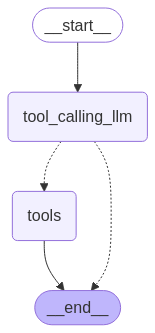

In [25]:
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
messages=graph.invoke({"messages":"1706.03762"})
for m in messages["messages"]:
    m.pretty_print()

InternalServerError: Error code: 503 - {'error': {'message': 'Service Unavailable', 'type': 'internal_server_error'}}

In [27]:
messages=graph.invoke({"messages":"Hi,My name is YTR"})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi,My name is YTR
================================== Ai Message ==================================

Hello! It's nice to meet you, YTR. How can I assist you today?
